# Introduction

In the previous notebook we introduced Gaussian conditioning. Here we use it to derive Bayesian linear regression. The key idea is that regression with Gaussian prior over weights and Gaussian observation noise can be written as conditioning a Gaussian random vector on noisy linear observations.

# Imports and Setup

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [2]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random
from matplotlib.axes import Axes

from src.gaussian import Gaussian

KEY = random.key(47)

# Problem Setup

In this notebook we consider linear regression framework of the form:
$$ y_i = \phi(x_i)^T w + \varepsilon_i $$

where:

* $(x_i, y_i)$ is an observation
* $w \sim \mathcal{N}(\mu_0, \Sigma_0)$ is a multivariate Gaussian representing regression weights
* $\varepsilon_i \sim \mathcal{N}(0, r^2)$ is noise made during $i^{\text{th}}$ observation
* $\phi$ is a feature map

In the stacked(matrix) form it can be written as:
$$ y = \Phi w + \varepsilon $$

with:

* $y \in \mathbb{R}^n$
* $\Phi \in \mathbb{R}^{n \times d}$
* $w \sim \mathcal{N}(\mu_0, \Sigma_0),\ \mu_0 \in \mathbb{R}^d,\ \Sigma_0 \in \mathbb{R}^{d \times d}$
* $\varepsilon \sim \mathcal{N}(0, r^2 I),\ I \in \mathbb{R}^{n \times n}$

Let us suppose we have obtained a posterior distribution $w \sim \mathcal{N}(\mu, \Sigma)$. For a new input vector $x_*$, the output of our model is, then:
$$ y_* = \phi(x_*)^T w + \varepsilon $$

To run inference of our model, we want to estimate:

* **Predictive mean**: the mean value of our prediction for a certain data point.
* **Predictive variance**: the variance of our prediction for a certain data point.

To calculate the predictive mean we will use:
$$ \begin{aligned}
\mathbb{E} [y_* \mid x_*, \mathcal{D}] &= \mathbb{E} [\phi(x_*)^T w + \varepsilon] \\
&= \phi(x_*)^T \underbrace{\mathbb{E}[w]}_{\mu} + \underbrace{\mathbb{E}[\varepsilon]}_{0} \\
&= \phi(x_*)^T \mu 
\end{aligned} $$
In a stacked form we can write:
$$ \boxed{\mathbb{E}[y \mid \Phi, \mathcal{D}] = \Phi \mu} $$

Predictive variance can be calculated in a same manner:
$$ \begin{aligned}
\text{Var}(y_* \mid x_*, \mathcal{D}) &= \text{Var}(\phi(x_*)^T w + \varepsilon) \\
&= \phi(x_*)^T \underbrace{\text{Var}(w)}_{\Sigma} \phi(x_*) + \underbrace{\text{Var}(\varepsilon)}_{r^2} \\
&= \phi(x_*)^T \Sigma \phi(x_*) + r^2
\end{aligned}$$
In a stacked form:
$$ \boxed{\text{Var}(y \mid \Phi, \mathcal{D}) = \text{diag}(\Phi \Sigma \Phi^T) + r^2} $$
only the diagonal values of the covariance matrix are taken since they represent the individual predictive variances.

Note that there are two sources of the uncertainty:
* **Parameter uncertainty:** the uncertainty related to the model's parameters
* **Observation noise:** the uncertainty related to the noise of the observations $\varepsilon_i$

One can understand them as:
* *Where could the true mean relationship be?*
* *Where could the next noisy observation be?*

For the plotting purposes only the parameter uncertainty (also known as **latent posterior uncertainty**) will be used in this notebook.

The "fitting" of the model will be performed using the Gaussian conditioning discussed in the last notebook.

In [3]:
def posterior_predictive(
    posterior: Gaussian,
    Phi: jnp.ndarray,
    r: float | None = None
):
    predictive_mean = Phi @ posterior.mu
    predictive_variance = jnp.diag(Phi @ posterior.Sigma @ Phi.T)

    if r is not None:
        predictive_variance += r**2
    
    return predictive_mean, predictive_variance

def fit_bayesian_posterior(
    prior: Gaussian,
    Phi: jnp.ndarray,
    y: jnp.ndarray,
    r: float
) -> Gaussian:
    R = r**2 * jnp.eye(Phi.shape[0])
    return prior.condition(Phi, y, R)

def plot_posterior_predictive(
    x_plot: jnp.ndarray,
    predictive_mean: jnp.ndarray, 
    predictive_variance: jnp.ndarray,
    data: tuple[jnp.ndarray, jnp.ndarray] | None = None,
    title: str | None = None,
    ax: Axes | None = None,
):
    if ax is None:
        ax = plt.gca()

    
    ax.plot(
        x_plot,
        predictive_mean,
        label=r"$\mu$",
    )

    ax.fill_between(
        x_plot,
        predictive_mean - jnp.sqrt(predictive_variance),
        predictive_mean + jnp.sqrt(predictive_variance),
        alpha=0.5,
        color="orange",
        label=r"$\mu \pm \sigma$",
    )

    ax.fill_between(
        x_plot,
        predictive_mean - 2 * jnp.sqrt(predictive_variance),
        predictive_mean + 2 * jnp.sqrt(predictive_variance),
        alpha=0.3,
        color="orange",
        label=r"$\mu \pm 2\sigma$",
    )

    if data is not None:
        x_data, y_data = data
        ax.scatter(x_data, y_data, label="Data", color = "green")

    if title is not None:
        ax.set_title(title)

    ax.legend()

    return ax

# Simple Synthetic Dataset

Let us consider an easy example where our data is:
$$ y_i = 7 + 4x_i + \varepsilon_i,\quad \varepsilon_i \sim \mathcal{N}(0, 3^2) $$

So we want to estimate the parameters $\beta_1 = 7$ and $\beta_2 = 4$. Thus, our $\phi$ should be:
$$ \phi(x) = \begin{bmatrix} 1 \\ x \end{bmatrix} $$

Let our prior be:
$$ w \sim \mathcal{N}(0, 5^2 I) $$

After initializing the prior and the transformation function, we can fit the Bayesian linear regression using `fit_bayesian_posterior` defined before.

Text(0.5, 1.0, 'Noisy Synthetic Data')

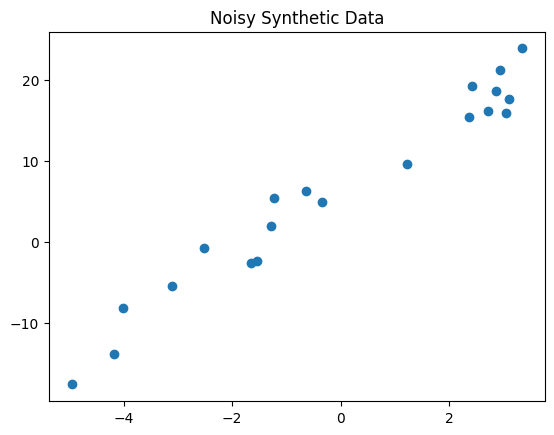

In [4]:
KEY, x_key, noise_key = random.split(KEY, 3)

x = random.uniform(x_key, shape = (20, ), minval = -5, maxval = 5)
noise = random.normal(noise_key, shape = (20, ))
y = 4 * x + 7 + noise * 3

plt.scatter(x, y)
plt.title('Noisy Synthetic Data')

In [5]:
prior_mean = jnp.zeros(2)
prior_cov = 5**2 * jnp.eye(2)

prior = Gaussian(prior_mean, prior_cov)
prior

Gaussian(mu=Array([0., 0.], dtype=float64), Sigma=Array([[25.,  0.],
       [ 0., 25.]], dtype=float64))

In [6]:
phi = lambda x: jnp.vstack([jnp.ones_like(x), x]).T

posterior = fit_bayesian_posterior(prior, phi(x), y, r=2)
posterior

Gaussian(mu=Array([6.51397216, 4.2201185 ], dtype=float64), Sigma=Array([[0.19854752, 0.00189295],
       [0.00189295, 0.02658705]], dtype=float64))

<Axes: title={'center': 'Posterior Predictive Distribution'}>

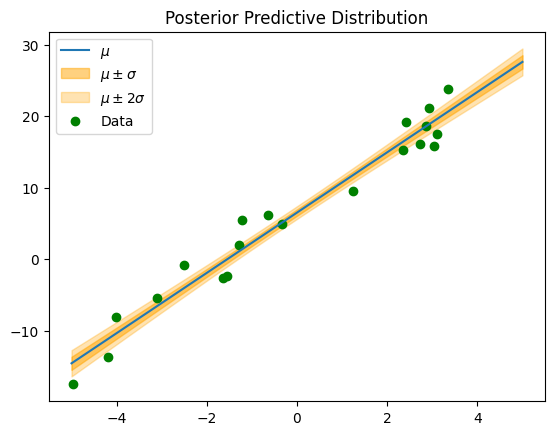

In [7]:
x_plot = jnp.arange(-5, 5.01, 0.01)
predictive_mean, predictive_variance = posterior_predictive(posterior, phi(x_plot))

plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, data = (x, y), title = "Posterior Predictive Distribution")

## Noise Variance Experiment

Note that we have set our prior and noise standard deviations as $\sigma_{0} = 5$ and $r = 2$. That means that our model is less "certain" about the prior compared to the observations. Recall from our last notebook, when we have multiplied Gaussians, the resulting variable one was closer to the one with the greater precision. Let us experiment with different values of noise variance to see the difference.

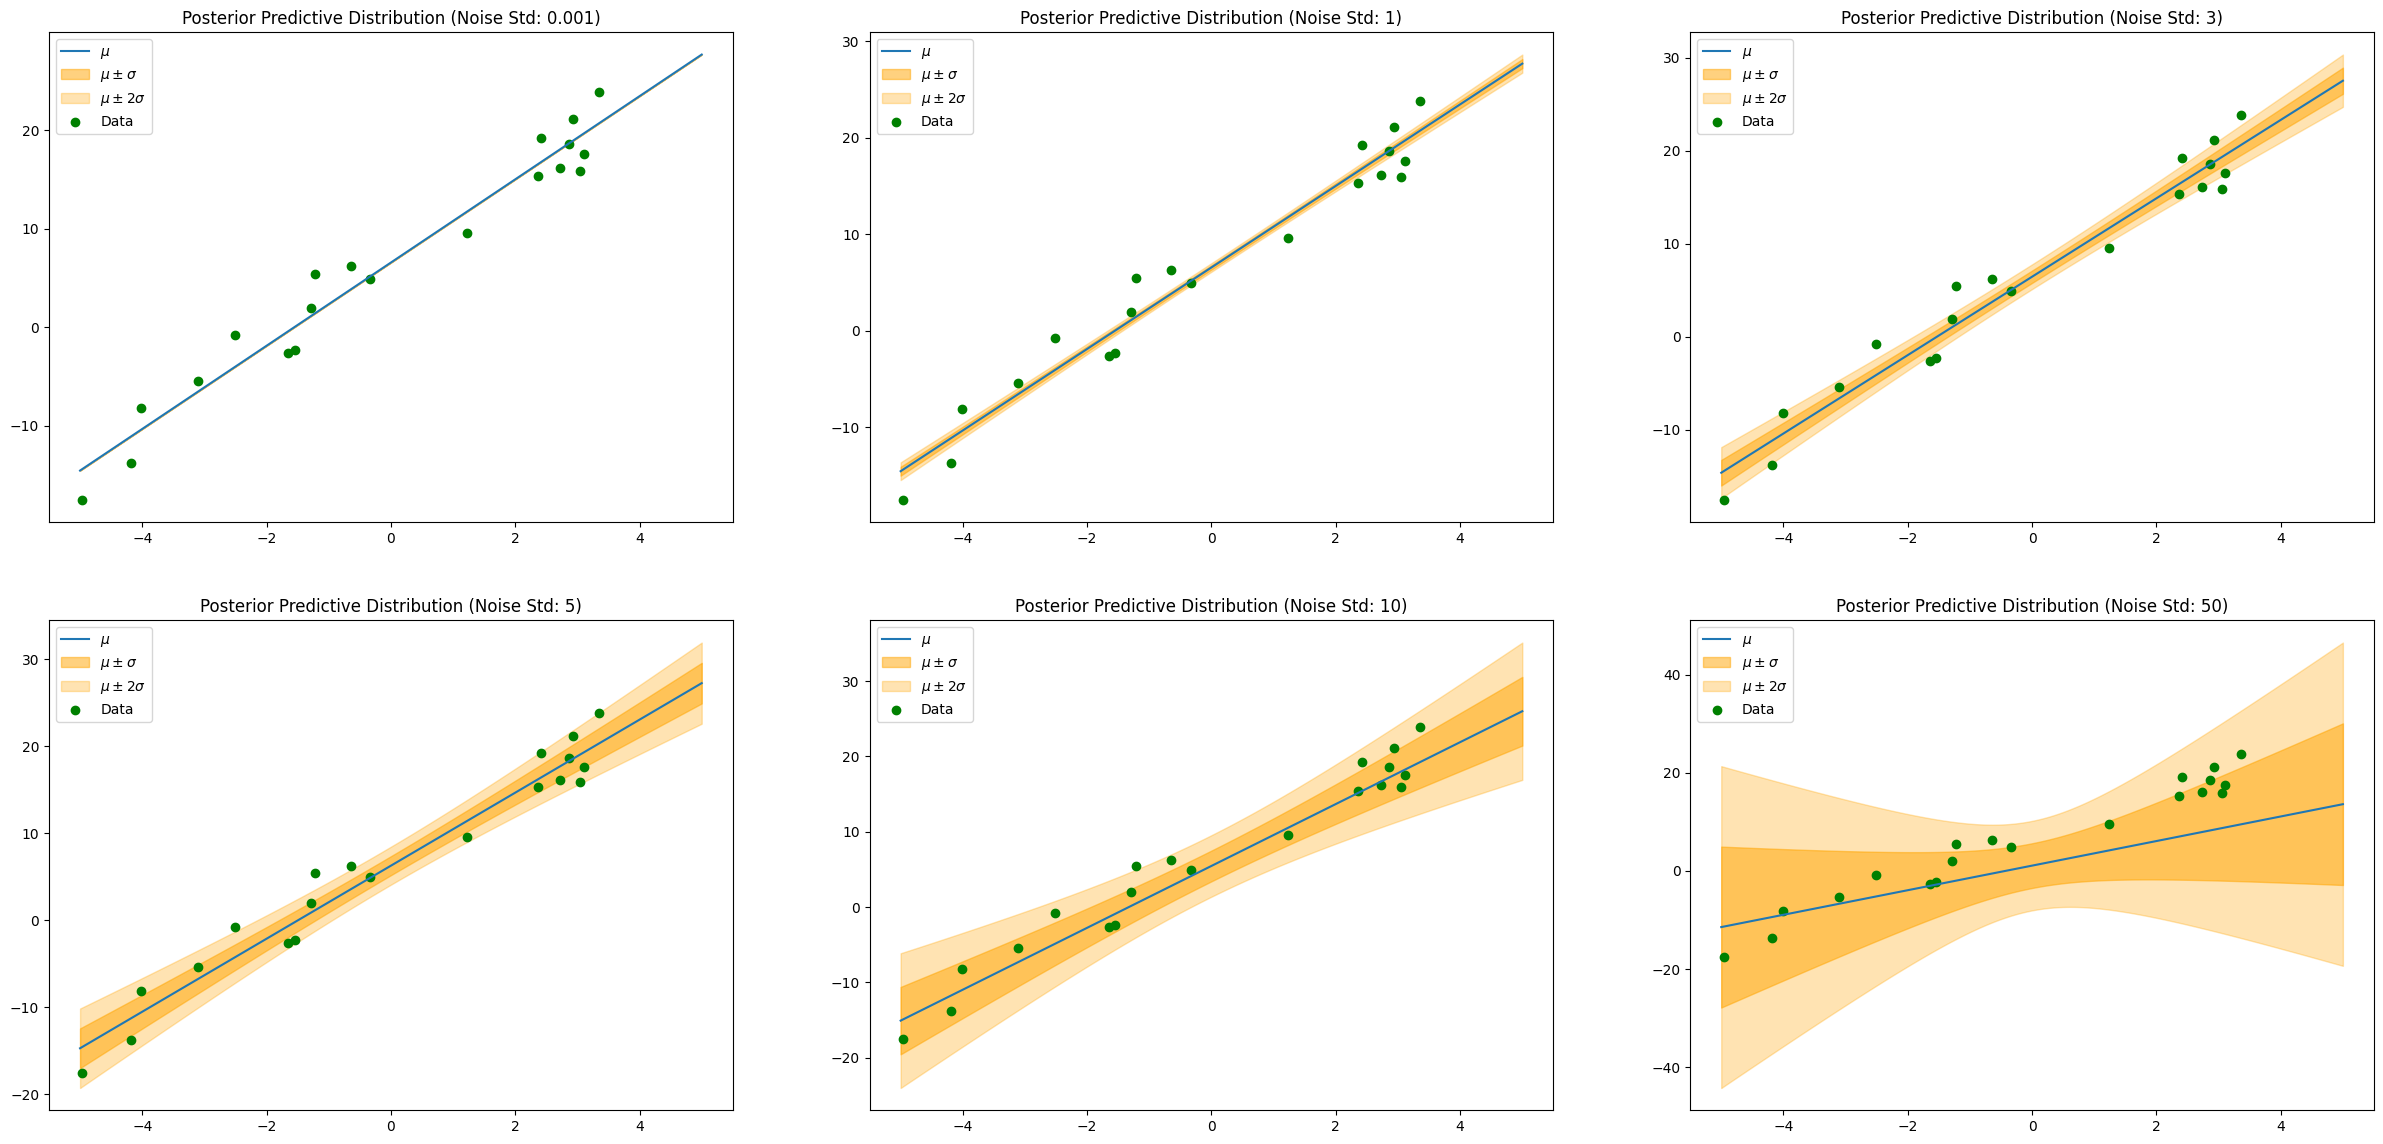

In [8]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (30, 14))

for i, noise_std in enumerate([0.001, 1, 3, 5, 10, 50]):
    posterior = fit_bayesian_posterior(prior, phi(x), y, r = noise_std)
    predictive_mean, predictive_variance = posterior_predictive(posterior, phi(x_plot))

    ax = axes.flatten()[i]
    ax = plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, data = (x, y), title = f"Posterior Predictive Distribution (Noise Std: {noise_std})", ax = ax)

From the figure we can see that for:

* $r=0.001$: the model is absurdly confident and treats almost every residual as impossible
* $r=1$: still overconfident
* $r=3$: correctly specified for this synthetic dataset
* $r=5$: slightly conservative; wider uncertainty and somewhat weaker learning
* $r=10$: the likelihood becomes less informative, so the prior matters more
* $r=50$: the model mostly ignores the data because it assumes observations are extremely noisy

Text(0.5, 1.0, 'Posterior Predictive Distribution')

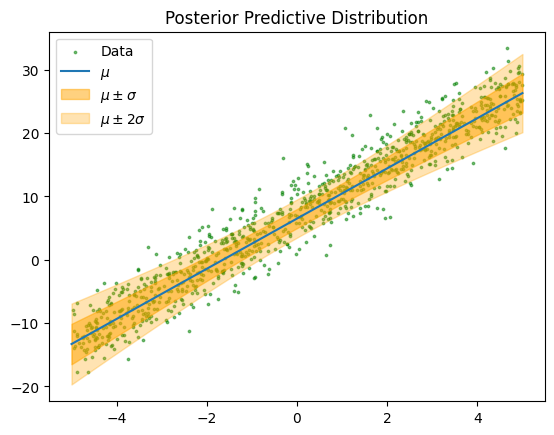

In [9]:
KEY, x_large_key, noise_large_key = random.split(KEY, 3)

x_large = random.uniform(x_large_key, shape = (1000, ), minval = -5, maxval = 5)
noise_large = random.normal(noise_large_key, shape = (1000, ))
y = 4 * x_large + 7 + noise_large * 3

posterior = fit_bayesian_posterior(prior, phi(x_large), y, r=50)

x_plot = jnp.arange(-5, 5.01, 0.01)
predictive_mean, predictive_variance = posterior_predictive(posterior, phi(x_plot))

plt.scatter(x_large, y, color = "green", label = "Data", s = 3, alpha = 0.5)
plt.plot(x_plot, predictive_mean, label = r"$\mu$")
plt.fill_between(x_plot, predictive_mean - jnp.sqrt(predictive_variance), predictive_mean + jnp.sqrt(predictive_variance), color = 'orange', alpha = 0.5, label = r"$\mu \pm \sigma$")
plt.fill_between(x_plot, predictive_mean - 2 * jnp.sqrt(predictive_variance), predictive_mean + 2 * jnp.sqrt(predictive_variance), color = 'orange', alpha = 0.3, label = r"$\mu \pm 2\sigma$")
plt.legend()
plt.title("Posterior Predictive Distribution")

So, as can be seen, the mean is now closer to the true regression parameters and the variance became smaller. So, even the model "trusts" more to its prior knowledge, it still learned the pattern of the observed data.

# Online Learning Example

Since, we can pass the observations one-by-one, Bayesian regression might be useful for online learning. As an experiment, let us start with a prior that we have defined in the previous section and update it using one data point at a time. Let us use $r = \sigma_0$ for this experiment.

This experiment can also be used to compare Bayesian regression to Ordinary Least Squares (OLS) regression. Let us train OLS with a subset of points and compare it to the Bayesian regression with online learning framework. For the OLS we will use:
$$ w_{\text{OLS}} = (\Phi^T \Phi)^{-1} \Phi^T y $$

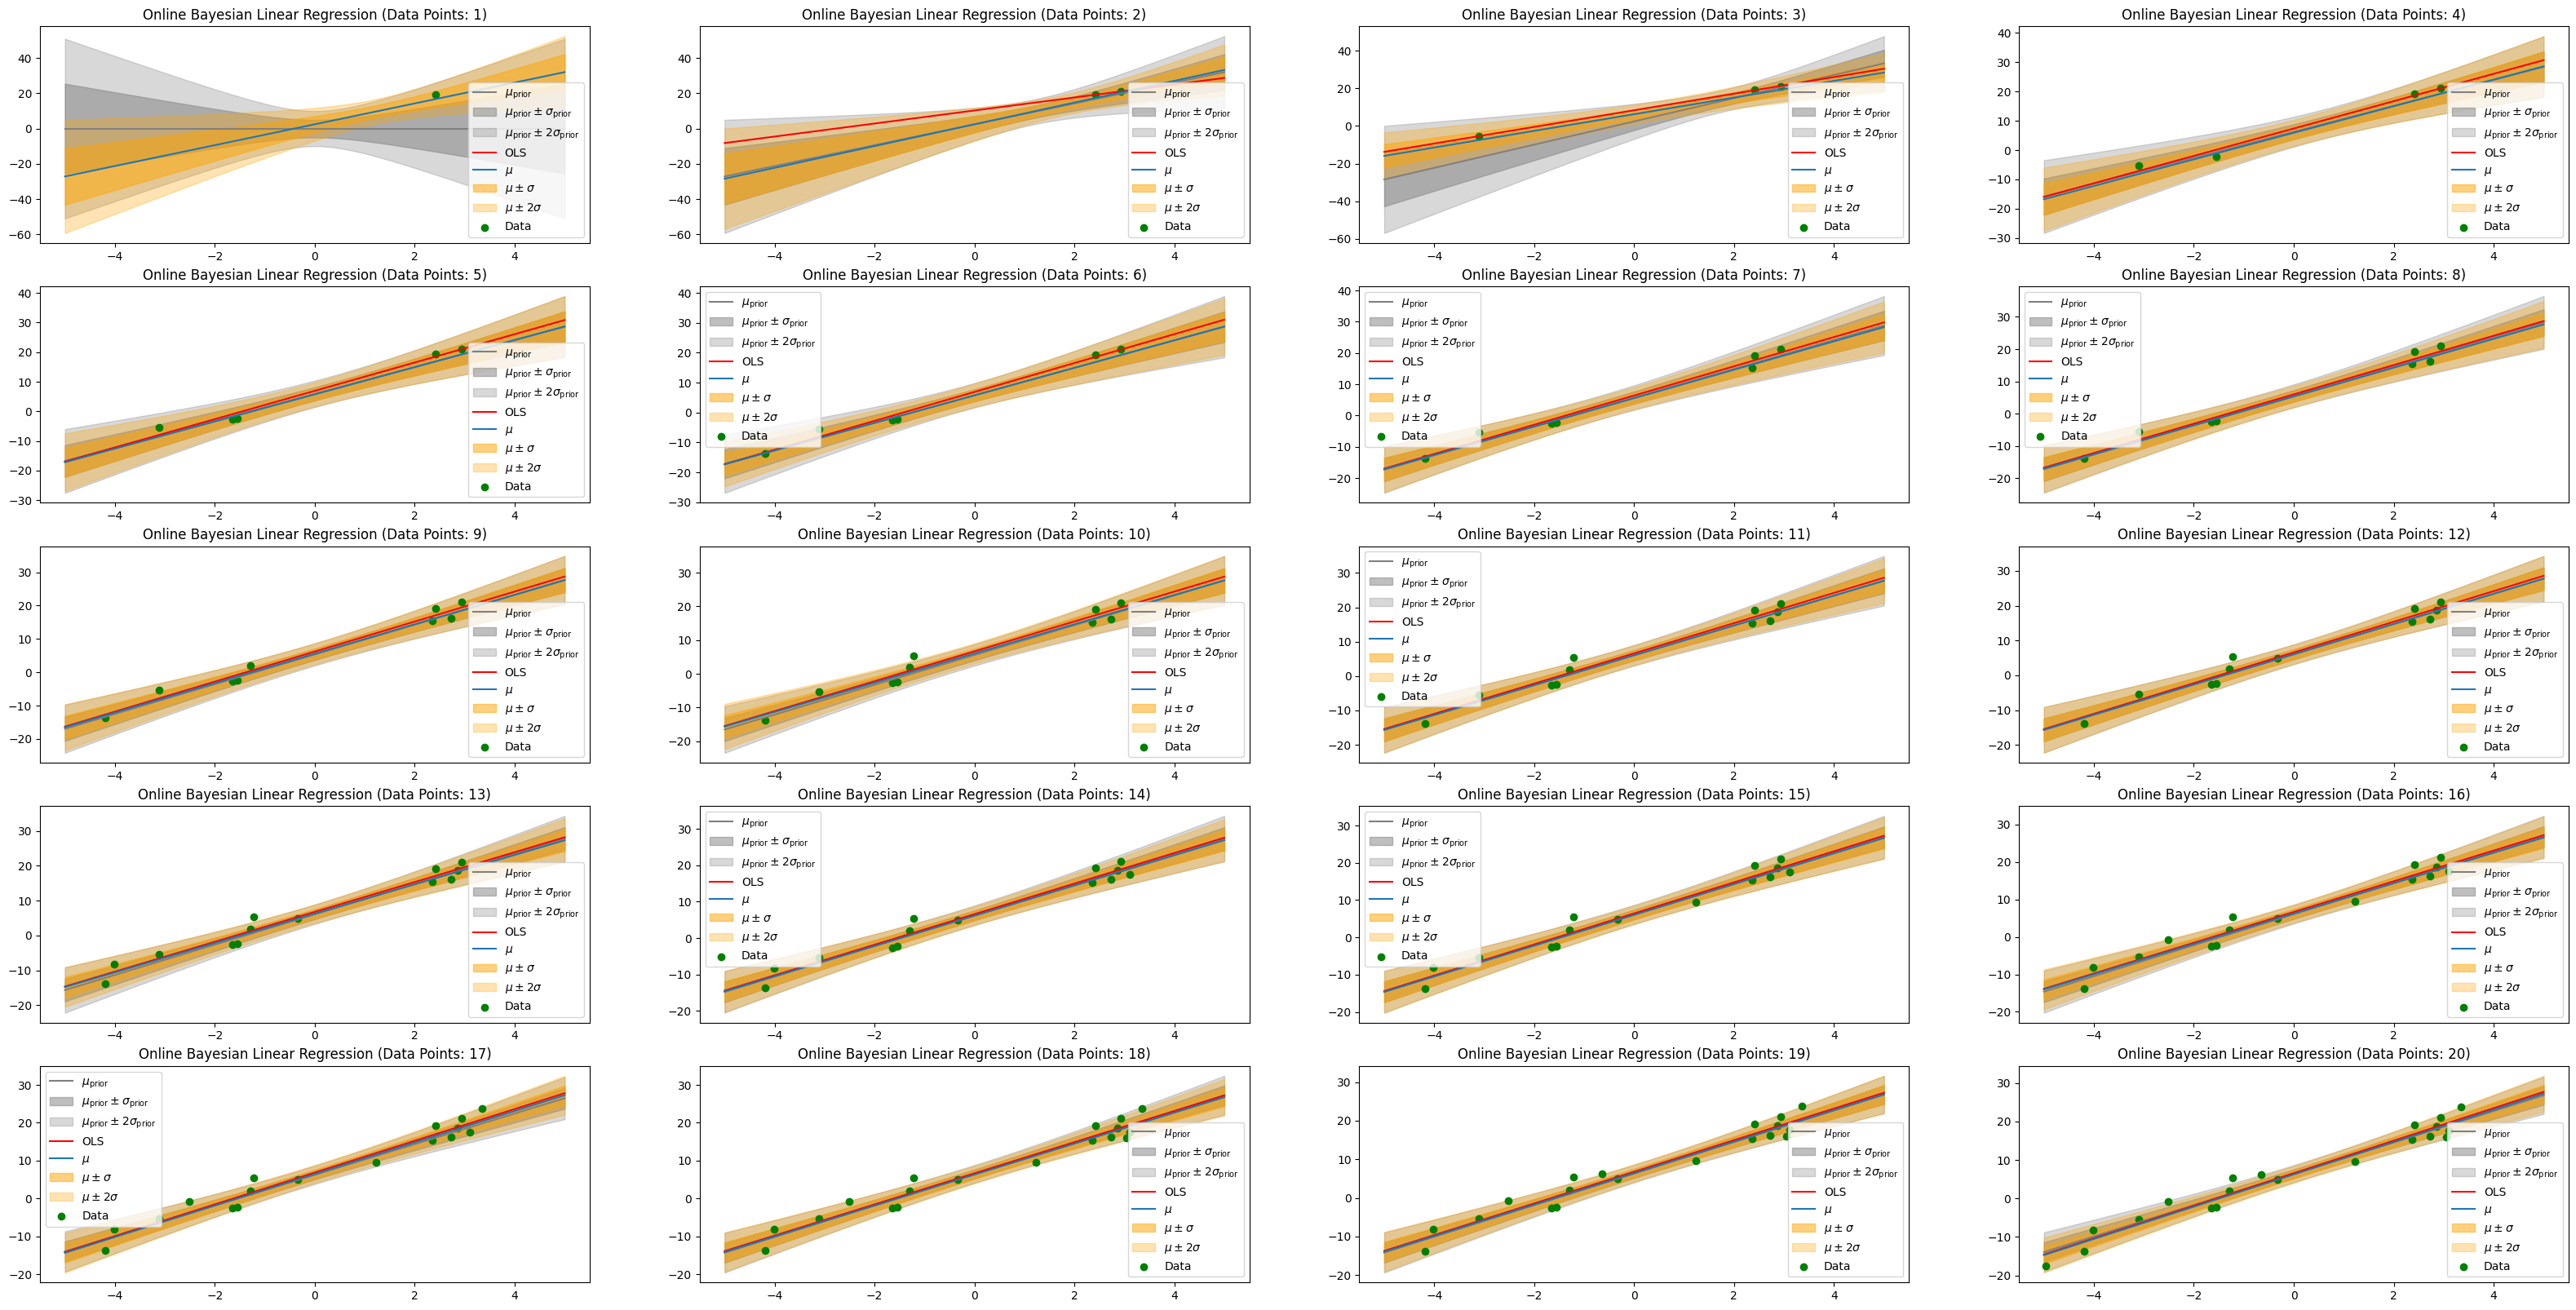

In [10]:
y = 4 * x + 7 + noise * 3

fig, axes = plt.subplots(nrows = 5, ncols = 4, figsize = (40, 20))

posterior = prior

for i in range(20):
    prior_mean, prior_variance = posterior_predictive(posterior, phi(x_plot))

    posterior = fit_bayesian_posterior(posterior, phi(x[i]), y[i], 5)
    predictive_mean, predictive_variance = posterior_predictive(posterior, phi(x_plot))

    ols = jnp.linalg.inv(phi(x[:i+1]).T @ phi(x[:i+1])) @ phi(x[:i+1]).T @ y[:i+1]
    y_ols = phi(x_plot) @ ols

    ax = axes.flatten()[i]

    ax.plot(x_plot, prior_mean, label = r"$\mu_{\text{prior}}$", color = "gray")
    ax.fill_between(x_plot, prior_mean - jnp.sqrt(prior_variance), prior_mean + jnp.sqrt(prior_variance), color = "gray", alpha = 0.5, label = r"$\mu_{\text{prior}} \pm \sigma_{\text{prior}}$")
    ax.fill_between(x_plot, prior_mean - 2 * jnp.sqrt(prior_variance), prior_mean + 2 * jnp.sqrt(prior_variance), color = "gray", alpha = 0.3, label = r"$\mu_{\text{prior}} \pm 2\sigma_{\text{prior}}$")
    
    ax.plot(x_plot, y_ols, color = "red", label = "OLS")

    ax = plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, data = (x[:i+1], y[:i+1]), title = f"Online Bayesian Linear Regression (Data Points: {i+1})", ax = ax)

From the graph above we can see that Bayesian regression basically converges to the OLS solution.

# Feature Map Comparison

Till now we have used 
$$ \phi(x) = \begin{bmatrix} 1 \\ x \end{bmatrix} $$
But we can use any other feature maps (sometimes called Basis Functions). Let us consider the most usual ones:

* **Polynomial Basis:** $\phi_{\text{poly}}(x) = (1, x, x^2, \dots)^T$
* **Fourier Basis:** $\phi_{\text{Fourier}}(x) = (\sin (\omega x), \cos (\omega x), \sin (2\omega x), \cos (2 \omega x), \dots)^T$
* **Radial Basis Functions(RBF):** $\phi_{\text{RBF}}(x) = (\exp \left( -\frac{(x - \mu_1)^2}{2 \sigma_{\text{RBF}}^2} \right), \exp \left( -\frac{(x - \mu_2)^2}{2 \sigma_{\text{RBF}}^2} \right), \dots)^T$

To compare these functions among each other, let us consider another regression problem:
$$ y_i = \sin(x_i) + 0.2 x_i + \varepsilon_i $$

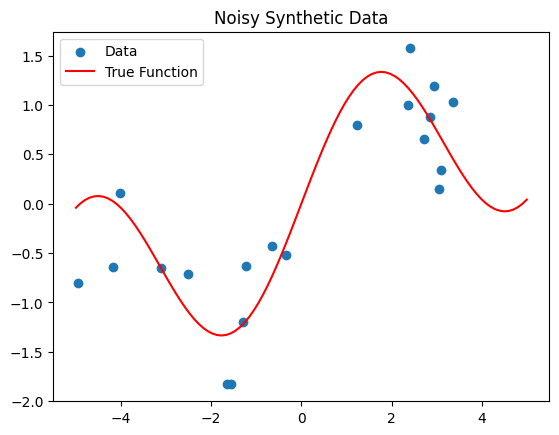

In [11]:
y = jnp.sin(x) + 0.2 * x + noise * 0.5

plt.scatter(x, y, label = "Data")
plt.plot(jnp.linspace(-5, 5, 100), 
         jnp.sin(jnp.linspace(-5, 5, 100)) + 0.2 * jnp.linspace(-5, 5, 100), 
         color = "red", label = "True Function")
plt.title("Noisy Synthetic Data")
plt.legend()

## Polynomial Basis

For polynomial basis we will use:
$$ \phi(x) = \begin{bmatrix} 1 \\ x \\ x^2 \\ x^{d} \end{bmatrix} $$
for some integer $d$.

In [12]:
def phi_polynomial(x: jnp.ndarray, degree: int) -> jnp.ndarray:
    return jnp.vstack([x**i for i in range(degree + 1)]).T

Let us start with quadratic values, $d=2$.

In [13]:
d = 2

prior_mean = jnp.zeros(d + 1)
prior_cov = 0.3**2 * jnp.eye(d + 1)
noise_std = 0.2

prior = Gaussian(prior_mean, prior_cov)

posterior = fit_bayesian_posterior(prior, phi_polynomial(x, d), y, r=noise_std)

<Axes: title={'center': 'Quadratic Regression'}>

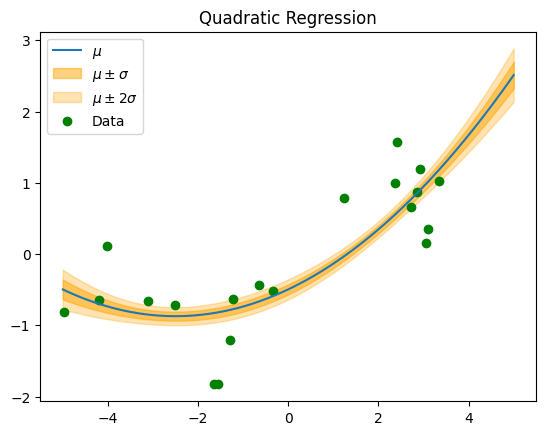

In [14]:
x_plot = jnp.arange(-5, 5.01, 0.01)
predictive_mean, predictive_variance = posterior_predictive(posterior, phi_polynomial(x_plot, d))

plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, data = (x, y), title = "Quadratic Regression")

As can be seen, the quadratic regression does not do well on the generated dataset. Let us consider polynomials of another degrees

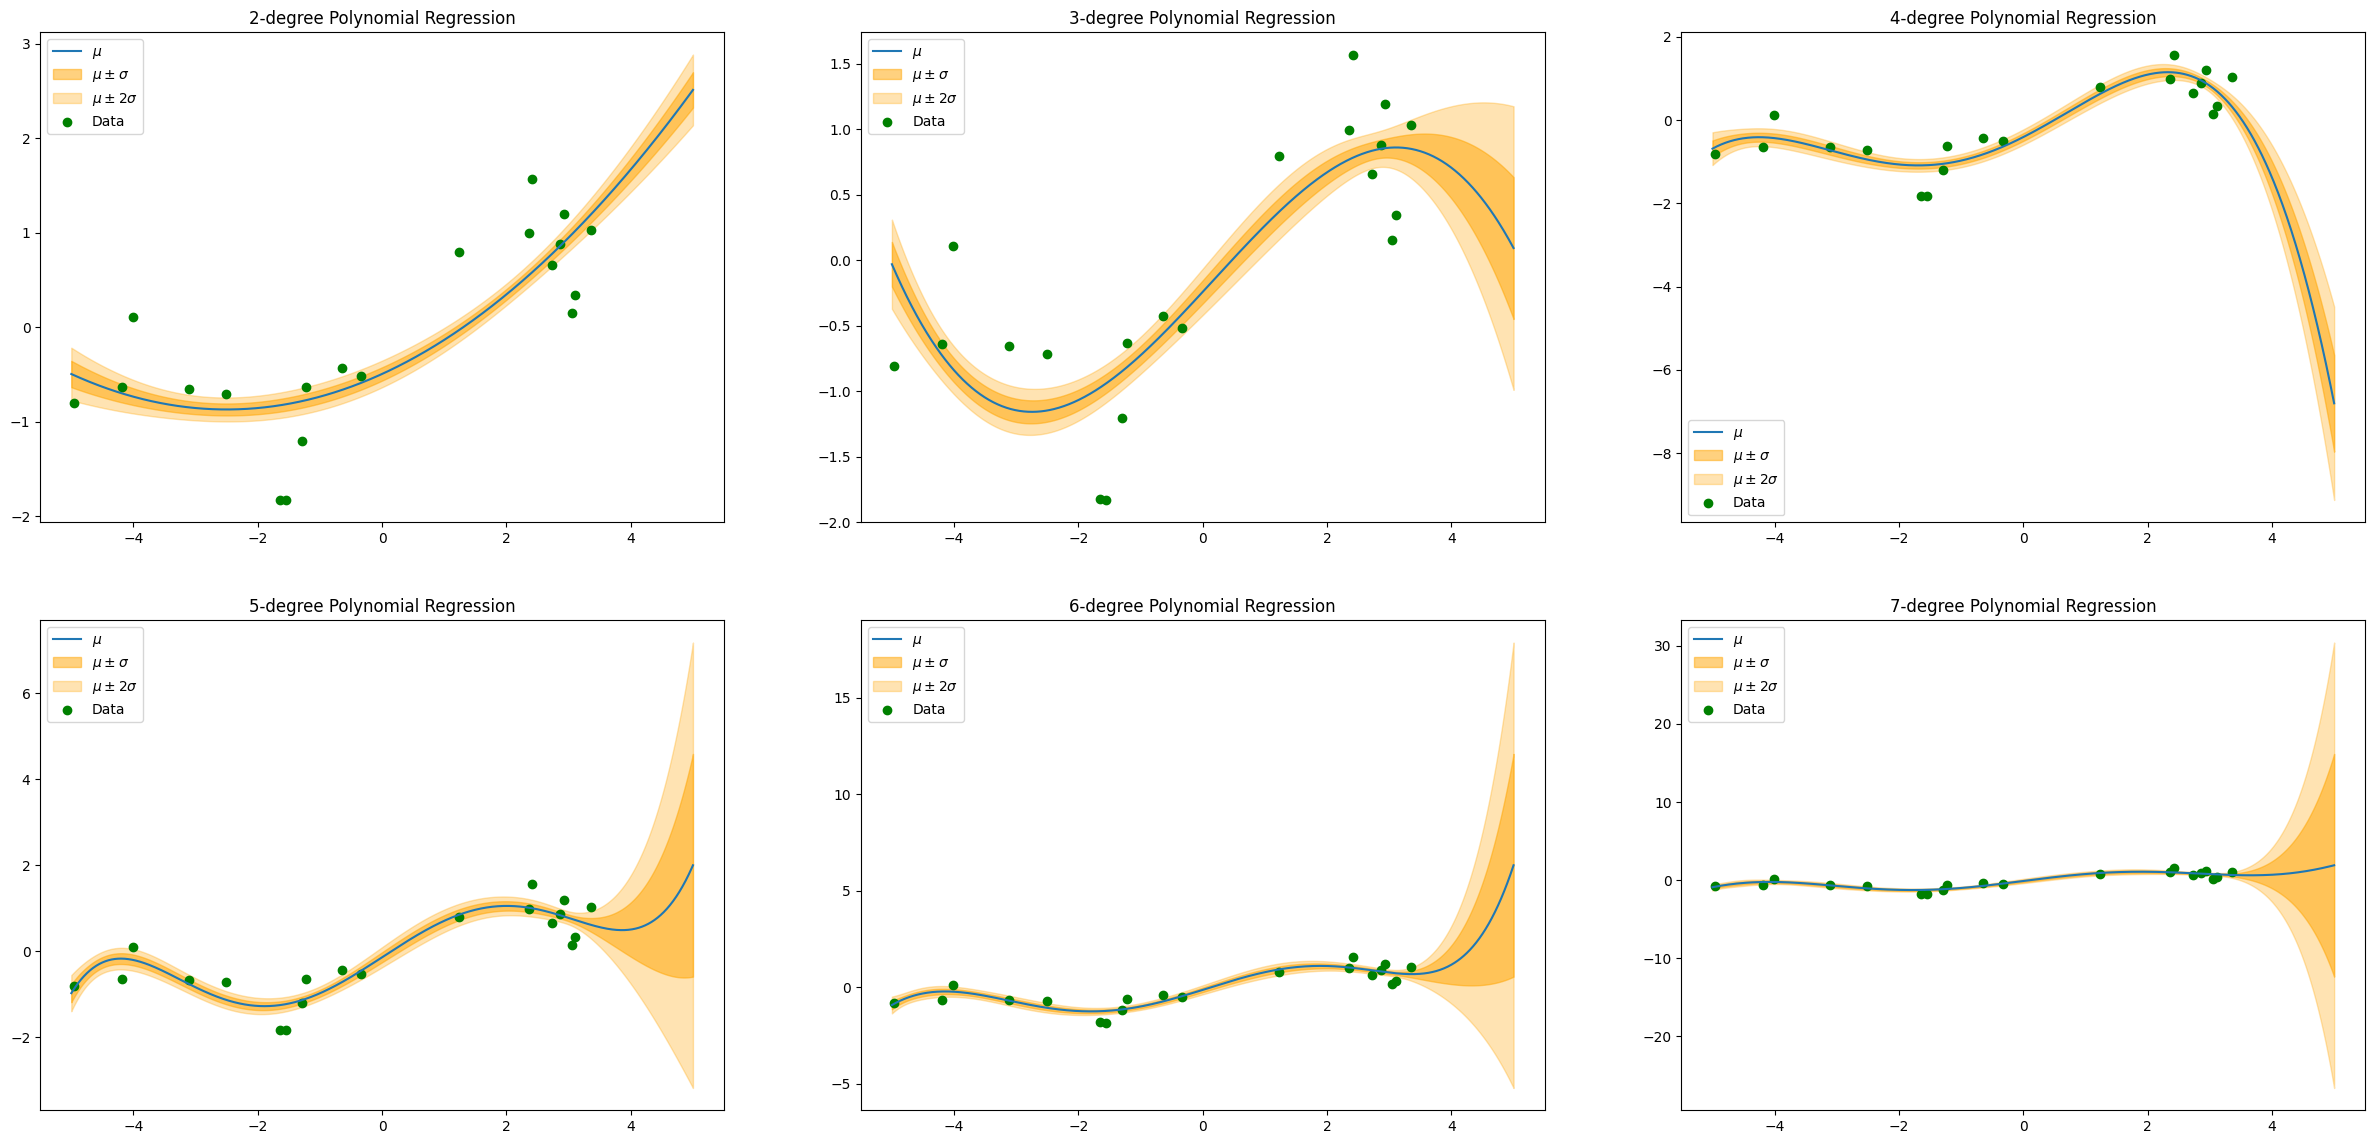

In [15]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (30, 14))

for i, d in enumerate([2, 3, 4, 5, 6, 7]):
    prior_mean = jnp.zeros(d+1)
    prior_cov = 0.3**2 * jnp.eye(d+1)

    prior = Gaussian(prior_mean, prior_cov)
    posterior = fit_bayesian_posterior(prior, phi_polynomial(x, d), y, r=noise_std)

    predictive_mean, predictive_variance = posterior_predictive(posterior, phi_polynomial(x_plot, d))

    ax = axes.flatten()[i]

    ax = plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, data = (x, y), title = f"{d}-degree Polynomial Regression", ax = ax)

## Fourier Basis

For the Fourier Basis, the following function will be used:
$$ \phi(x) = \begin{bmatrix} \sin (\omega x) \\ \cos (\omega x) \\ \sin (2 \omega x) \\ \cos(2 \omega x) \\ \vdots \end{bmatrix} $$

here, $\omega$ is an angular frequency:

* small $|\omega|$: large-scale patterns
* large $|\omega|$: fine-scale patterns

Fourier features are useful for periodic or oscillatory functions. It might help a bit with the periodicity in our $f$.

In [16]:
def phi_fourier(x: jnp.ndarray, omega: float, degree: int) -> jnp.ndarray:
    return jnp.vstack([jnp.hstack([[jnp.sin(omega * i * xi), jnp.cos(omega * i * xi)] for i in range(1, degree + 1)]) for xi in x])

In [17]:
omega = 1.0
d = 2

prior_mean = jnp.zeros(2 * d)
prior_cov = 0.3**2 * jnp.eye(2 * d)
noise_std = 0.2

prior = Gaussian(prior_mean, prior_cov)

posterior = fit_bayesian_posterior(prior, phi_fourier(x, omega, d), y, r=noise_std)

<Axes: title={'center': 'Fourier Basis Regression'}>

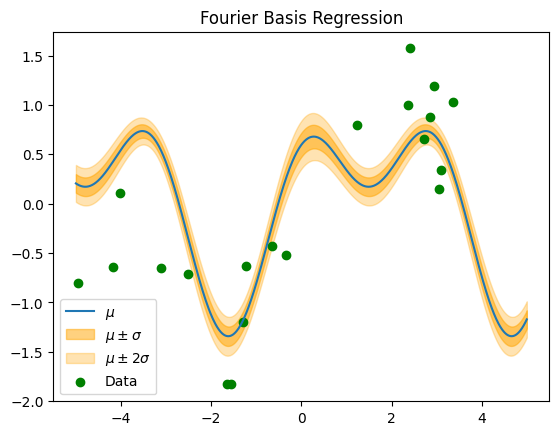

In [18]:
x_plot = jnp.arange(-5, 5.01, 0.01)
predictive_mean, predictive_variance = posterior_predictive(posterior, phi_fourier(x_plot, omega, d))
plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, (x, y), "Fourier Basis Regression")

$\omega = 1$ worked out well, but let us see how the results will change if we consider smaller or greater values of $\omega$.

<Axes: title={'center': 'Fourier Basis Regression ($\\omega = 0.1$)'}>

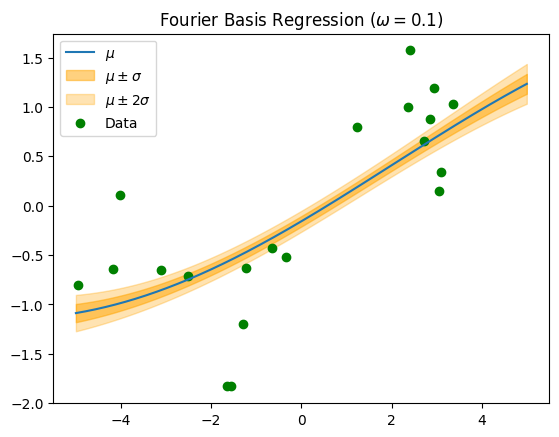

In [19]:
omega = 0.1

posterior = fit_bayesian_posterior(prior, phi_fourier(x, omega, d), y, r=noise_std)

x_plot = jnp.arange(-5, 5.01, 0.01)
predictive_mean, predictive_variance = posterior_predictive(posterior, phi_fourier(x_plot, omega, d))
plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, (x, y), rf"Fourier Basis Regression ($\omega = {omega}$)")

<Axes: title={'center': 'Fourier Basis Regression ($\\omega = 2.0$)'}>

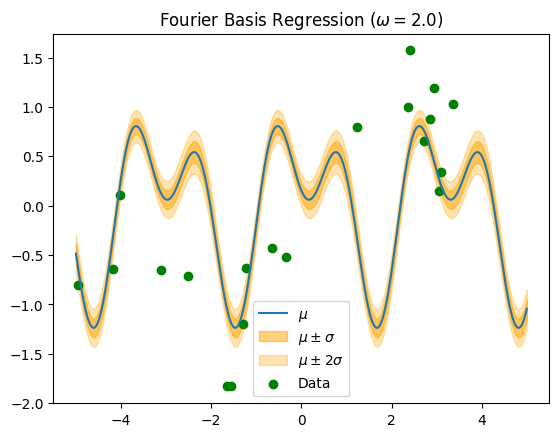

In [20]:
omega = 2.0

posterior = fit_bayesian_posterior(prior, phi_fourier(x, omega, d), y, r=noise_std)


x_plot = jnp.arange(-5, 5.01, 0.01)
predictive_mean, predictive_variance = posterior_predictive(posterior, phi_fourier(x_plot, omega, d))
plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, (x, y), rf"Fourier Basis Regression ($\omega = {omega}$)")

As expected, smaller values of $|\omega|$ result in larger scale oscillations, while greater values of $|\omega|$ result in finer scale oscillations. Now let us try to use more features.

In [21]:
omega = 1.0
d = 3

prior_mean = jnp.zeros(2 * d)
prior_cov = 0.3**2 * jnp.eye(2 * d)
noise_std = 0.2

prior = Gaussian(prior_mean, prior_cov)

posterior = fit_bayesian_posterior(prior, phi_fourier(x, omega, d), y, r=noise_std)

<Axes: title={'center': 'Fourier Basis Regression'}>

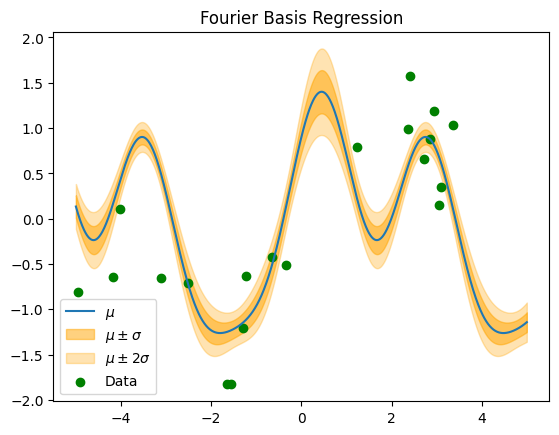

In [22]:
x_plot = jnp.arange(-5, 5.01, 0.01)
predictive_mean, predictive_variance = posterior_predictive(posterior, phi_fourier(x_plot, omega, d))
plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, (x, y), "Fourier Basis Regression")

Pretty interesting figure, it changed its shape since now we are not only considering $\omega x$ and $2 \omega x$ in the trigonometric functions but also $3 \omega x$, creating another feature with smaller oscillations.

## Radial Basis Functions (RBF)

RBF features create localized basis functions, so the model behaves like a smooth weighted combination of bumps. The formula for this is as follows:
$$ \phi(x) = \begin{bmatrix} \exp \left( -\frac{(x - \mu_1)^2}{2 \sigma^2} \right) \\ \exp \left( -\frac{(x - \mu_2)^2}{2 \sigma^2} \right) \\ \vdots \end{bmatrix} $$

Where $\mu_1, \mu_2, \dots, \mu_d$ are some points in space where the basis functions are localized. As an example, we will equally divide our domain into $d+1$ segments and get their border points. $\sigma$ controls how "narrow" is our basis function.

In [23]:
def phi_rbf(x: jnp.ndarray, centers: jnp.ndarray, sigma: float) -> jnp.ndarray:
    return jnp.exp(-jnp.square(x[:, None] - centers[None, :]) / (2 * sigma**2))

In [24]:
d = 3
centers = jnp.linspace(-5, 5, d + 2)[1:-1]
sigma_rbf = 1.0

prior_mean = jnp.zeros(d)
prior_cov = 0.3**2 * jnp.eye(d)
noise_std = 0.2

prior = Gaussian(prior_mean, prior_cov)

posterior = fit_bayesian_posterior(prior, phi_rbf(x, centers, sigma_rbf), y, r=noise_std)

<Axes: title={'center': 'RBF Regression'}>

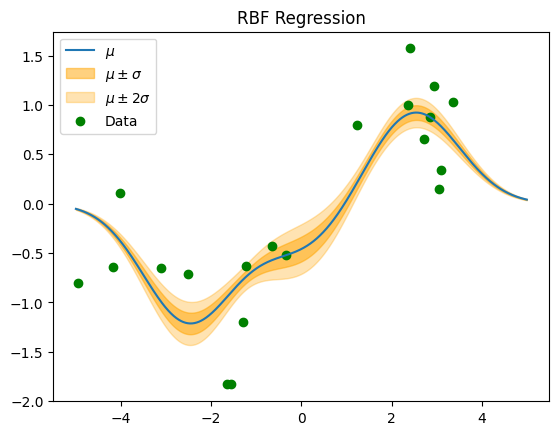

In [25]:
x_plot = jnp.arange(-5, 5.01, 0.01)
predictive_mean, predictive_variance = posterior_predictive(posterior, phi_rbf(x_plot, centers, sigma_rbf))
plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, (x, y), "RBF Regression")

One can notice local peaks near $x = -2.5, 0, 2.5$, which are the centers of our local basis functions. Now, let us see how $\sigma$ affects the trained model

In [26]:
sigma_rbf = 0.1

posterior = fit_bayesian_posterior(prior, phi_rbf(x, centers, sigma_rbf), y, r=noise_std)

<Axes: title={'center': 'RBF Regression ($\\sigma = 0.1$)'}>

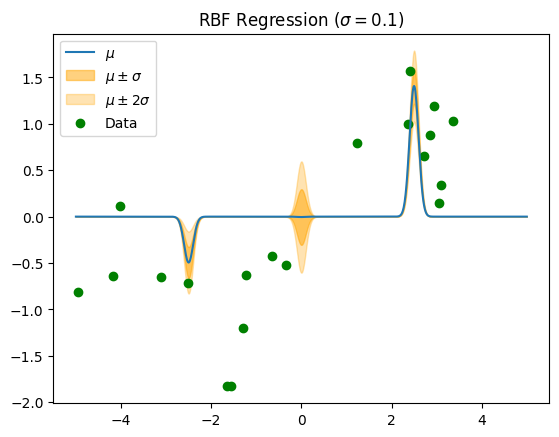

In [27]:
x_plot = jnp.arange(-5, 5.01, 0.01)
predictive_mean, predictive_variance = posterior_predictive(posterior, phi_rbf(x_plot, centers, sigma_rbf))
plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, (x, y), rf"RBF Regression ($\sigma = {sigma_rbf}$)")

Since our $\sigma$ became significantly smaller, our posterior also cares more about the centers of our basis functions

In [28]:
sigma_rbf = 3.0

posterior = fit_bayesian_posterior(prior, phi_rbf(x, centers, sigma_rbf), y, r=noise_std)

<Axes: title={'center': 'RBF Regression ($\\sigma = 3.0$)'}>

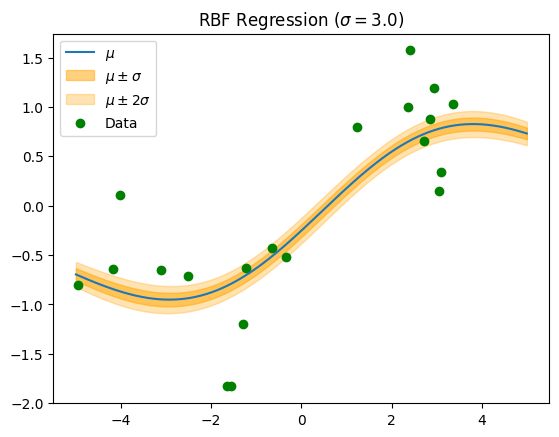

In [29]:
x_plot = jnp.arange(-5, 5.01, 0.01)
predictive_mean, predictive_variance = posterior_predictive(posterior, phi_rbf(x_plot, centers, sigma_rbf))
plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, (x, y), rf"RBF Regression ($\sigma = {sigma_rbf}$)")

Now $\sigma$ made our posterior too broad, not caring much about the centers of the basis functions. Now let us see what happens if we increase the number of basis functions

In [30]:
d = 7
centers = jnp.linspace(-5, 5, d + 2)[1:-1]
sigma_rbf = 1.0

prior_mean = jnp.zeros(d)
prior_cov = 0.3**2 * jnp.eye(d)
noise_std = 0.2

prior = Gaussian(prior_mean, prior_cov)

posterior = fit_bayesian_posterior(prior, phi_rbf(x, centers, sigma_rbf), y, r=noise_std)

<Axes: title={'center': 'RBF Regression'}>

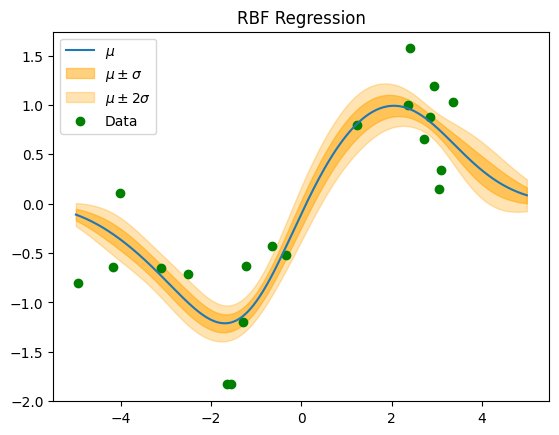

In [31]:
x_plot = jnp.arange(-5, 5.01, 0.01)
predictive_mean, predictive_variance = posterior_predictive(posterior, phi_rbf(x_plot, centers, sigma_rbf))
plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, (x, y), "RBF Regression")

One can also use custom basis function centers depending on the problem.

# Real Dataset Example

Now let us try to model something real. Auto MPG dataset from Kaggle ([link](https://www.kaggle.com/datasets/uciml/autompg-dataset)) is a good example since we can model weight vs MPG of the cars.

In [32]:
import pandas as pd

df = pd.read_csv("../data/auto-mpg.csv")

df = df[["weight", "mpg"]].dropna()

x = jnp.asarray(df["weight"].to_numpy())
y = jnp.asarray(df["mpg"].to_numpy())

In [33]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 47)

x_train.shape, x_test.shape

((318,), (80,))

Text(0.5, 1.0, 'MPG Distribution')

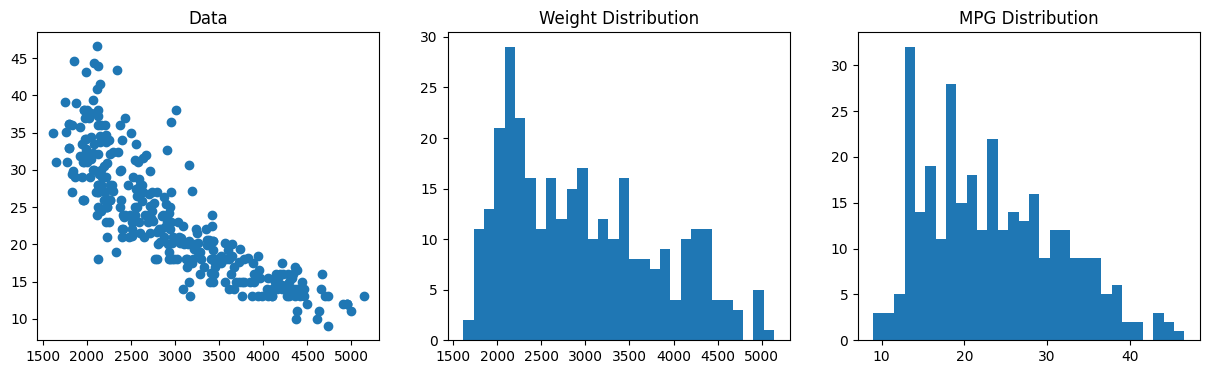

In [34]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (15, 4))

axes[0].scatter(x_train, y_train)
axes[0].set_title("Data")

axes[1].hist(x_train, bins = 30)
axes[1].set_title("Weight Distribution")

axes[2].hist(y_train, bins = 30)
axes[2].set_title("MPG Distribution")

We can standardize the values to make them live in similar scales.

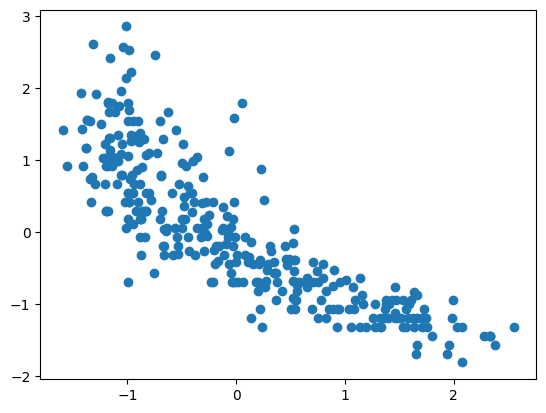

In [35]:
x_mean = x_train.mean()
x_std = x_train.std()
y_mean = y_train.mean()
y_std = y_train.std()

x_train = (x_train - x_mean) / x_std
y_train = (y_train - y_mean) / y_std

x_test = (x_test - x_mean) / x_std
y_test = (y_test - y_mean) / y_std

plt.scatter(x_train, y_train)

In [36]:
x_plot = jnp.arange(x_train.min() - 0.1, x_train.max() + 0.2, 0.01)

Let us try two different models for this example:
* $y = \beta_1 + \beta_2 x + \varepsilon$
* $y = \beta_1 + \beta_2 x + \beta_3 x^2 + \varepsilon$
* $y = \beta_1 + \beta_2 x + \beta_3 \log (5 + x) + \varepsilon$

## Model 1: Linear Regression

In [37]:
prior_mean = jnp.zeros(2)
prior_cov = jnp.eye(2)

prior = Gaussian(prior_mean, prior_cov)

<Axes: title={'center': 'Linear Regression on Auto MPG Dataset'}>

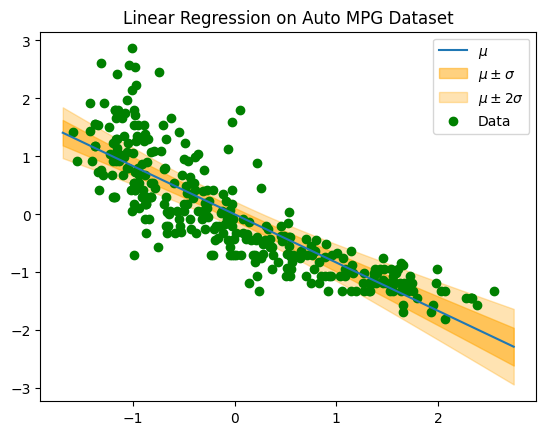

In [38]:
posterior_linear = fit_bayesian_posterior(prior, phi(x_train), y_train, r=2)

predictive_mean, predictive_variance = posterior_predictive(posterior_linear, phi(x_plot))
plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, data = (x_train, y_train), title = "Linear Regression on Auto MPG Dataset")

## Model 2: Quadratic Regression

In [39]:
prior_mean = jnp.zeros(3)
prior_cov = jnp.eye(3)

prior = Gaussian(prior_mean, prior_cov)

<Axes: title={'center': 'Quadratic Regression on Auto MPG Dataset'}>

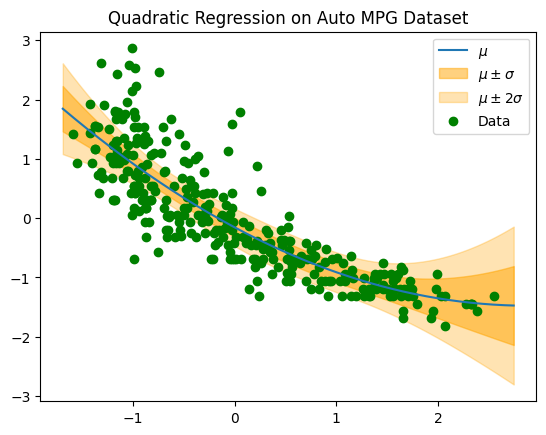

In [40]:
posterior_quadratic = fit_bayesian_posterior(prior, phi_polynomial(x_train, degree = 2), y_train, r=2)

predictive_mean, predictive_variance = posterior_predictive(posterior_quadratic, phi_polynomial(x_plot, degree = 2))
plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, data = (x_train, y_train), title = "Quadratic Regression on Auto MPG Dataset")

## Model 3: Logarithmic Regression

In [41]:
prior_mean = jnp.zeros(3)
prior_cov = jnp.eye(3)

prior = Gaussian(prior_mean, prior_cov)

<Axes: title={'center': 'Logarithmic Regression on Auto MPG Dataset'}>

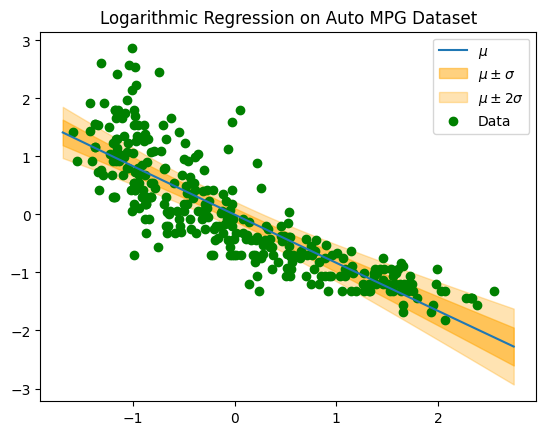

In [42]:
phi_log = lambda x: jnp.vstack([jnp.ones_like(x), x, jnp.log(5 + x)]).T

posterior_logarithmic = fit_bayesian_posterior(prior, phi_log(x_train), y_train, r=2)

predictive_mean, predictive_variance = posterior_predictive(posterior_logarithmic, phi_log(x_plot))
plot_posterior_predictive(x_plot, predictive_mean, predictive_variance, data = (x_train, y_train), title = "Logarithmic Regression on Auto MPG Dataset")

## Model Assessment

One can assess the models using standard regression metrics as $R^2$ or mean squared error. However, since the predictive posterior is a probability distribution, we can also assess such metrics as:

* predictive log-likelihood
* negative log predictive density
* prediction-interval coverage

and many others.

Let us use $R^2$ relative to the model's expected value and predictive log-likelihood:
$$ \log p(y \mid \mathcal{D}) = -\frac{1}{2} n \log (2 \pi) - \frac{1}{2} \sum_{i=1}^{n} \left(\log \sigma_i^2 + \frac{(y_i - \mu_i)^2}{\sigma_i^2} \right) $$

Note that the greater the log-likelihood is, the better the model is.

In [43]:
def r2(y_true:jnp.ndarray, y_mean_pred: jnp.ndarray) -> float:
    ss_res = jnp.sum(jnp.square(y_true - y_mean_pred))
    ss_tot = jnp.sum(jnp.square(y_true - jnp.mean(y_true)))
    return 1 - (ss_res / ss_tot)

def predictive_log_likelihood(y_true: jnp.ndarray, y_mean_pred: jnp.ndarray, y_var_pred: jnp.ndarray) -> float:
    n = y_true.shape[0]
    log_likelihood = -0.5 * n * jnp.log(2 * jnp.pi) - 0.5 * jnp.sum(jnp.log(y_var_pred)) - 0.5 * jnp.sum((y_true - y_mean_pred)**2 / y_var_pred)
    return log_likelihood

In [44]:
y_linear_mean, y_linear_variance = posterior_predictive(posterior_linear, phi(x_test), r=2)
y_quadratic_mean, y_quadratic_variance = posterior_predictive(posterior_quadratic, phi_polynomial(x_test, degree = 2), r=2)
y_logarithmic_mean, y_logarithmic_variance = posterior_predictive(posterior_logarithmic, phi_log(x_test), r=2)

In [45]:
print(f"linear basis:\nr2: {r2(y_test, y_linear_mean):.4f}\npredictive log-likelihood: {predictive_log_likelihood(y_test, y_linear_mean, y_linear_variance):.4f}\n")
print(f"quadratic basis:\nr2: {r2(y_test, y_quadratic_mean):.4f}\npredictive log-likelihood: {predictive_log_likelihood(y_test, y_quadratic_mean, y_quadratic_variance):.4f}\n")
print(f"logarithmic basis:\nr2: {r2(y_test, y_logarithmic_mean):.4f}\npredictive log-likelihood: {predictive_log_likelihood(y_test, y_logarithmic_mean, y_logarithmic_variance):.4f}\n")

linear basis:
r2: 0.5968
predictive log-likelihood: -132.0366

quadratic basis:
r2: 0.5980
predictive log-likelihood: -132.1161

logarithmic basis:
r2: 0.5973
predictive log-likelihood: -132.0347



The quadratic basis gave the best point predictions, while the logarithmic basis achieved the strongest probabilistic performance, though the differences between all three models were negligible.